# 2.15 — La donnée comme responsabilité : inférence d'appartenance et confidentialité différentielle

**Navigation** : [<< 2.14b-XAI-Shap-Attribution-Causal-Bridge](2.14b-XAI-Shap-Attribution-Causal-Bridge.ipynb) | [Index](README.md) | [Suivant >>](../README.md)

**Kernel** : Python 3 — **Durée** : 45 min — **CPU** : < 5 min

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. **Mesurer** une fuite de données d'entraînement par une attaque par inférence d'appartenance (*membership inference attack*), et expliquer pourquoi un modèle qui mémorise est un modèle qui fuit.
2. **Définir** la confidentialité différentielle (paramètres epsilon et delta) et **implémenter** le mécanisme de Laplace puis un DP-SGD pédagogique, à la main en numpy.
3. **Tracer** la courbe utilité/confidentialité (epsilon vs accuracy) sur plusieurs seeds, et la **confronter** à la bibliothèque de référence du domaine, `diffprivlib` d'IBM.
4. **Documenter** un jeu de données (datasheet) et un modèle (model card) avec le contenu réel de ce notebook, pas un gabarit vide.

### Prérequis

- **2.5-Biais-Variance-CV-ROC** : découpe train/test, accuracy, courbe ROC et AUC.
- **2.5b-Calibration-Probabilites** : ce que vaut une probabilité prédite par un modèle.
- **2.5c-Equite-Sous-Groupes** : pourquoi la performance moyenne ne suffit pas à juger un modèle.
- Bases de numpy et de la descente de gradient (**2.2-Descente-de-gradient**, **2.3-Regression-lineaire-logistique**).

### Plan

1. Le problème : le modèle se souvient de ses données (attaque par inférence d'appartenance).
2. La confidentialité différentielle : mécanisme de Laplace, DP-SGD, courbe utilité/confidentialité, comparaison avec `diffprivlib`.
3. Documenter : datasheet du jeu de données, model card du modèle.
4. Exercices, puis conclusion.

## Introduction

Les notebooks précédents ont appris à **juger** un modèle : la courbe ROC et l'accuracy (**2.5-Biais-Variance-CV-ROC**), la calibration des probabilités (**2.5b-Calibration-Probabilites**), l'équité entre sous-groupes (**2.5c-Equite-Sous-Groupes**). Tous partagent une question posée au modèle : *que vaut ta prédiction ?* Ce notebook pose une question différente, et plus inconfortable : ***que révèlent tes prédictions sur tes données d'entraînement ?***

L'enjeu est concret. Un hôpital entraîne un modèle de diagnostic sur des dossiers patients. Le modèle est excellent, on le déploie, des tiers l'interrogent. Le jeu étant public et canonique, nous jouerons le scénario où ces données sont **sensibles** : ce sont des mesures issues de patientes réelles, et l'appartenance au jeu d'entraînement est elle-même une information médicale (« cette personne a été prélevée pour suspicion de tumeur »). Nous allons montrer, expérience à l'appui, qu'un modèle sans précaution **confirme cette appartenance mieux que le hasard**, puis construire la réponse standard du domaine : la **confidentialité différentielle** (Dwork et Roth, 2014), et enfin la **documentation** (datasheet, model card), troisième pilier de la responsabilité des données.

La démarche est délibérément incrémentale : on **mesure la fuite** (partie 1), on **borne mécaniquement** ce que le modèle peut révéler (partie 2), on **documente** ce qui a été fait (partie 3).

## 1. Le problème : le modèle se souvient de ses données

Une **attaque par inférence d'appartenance** (*membership inference attack*, Shokri et al., 2017) répond à une question binaire : *cette ligne était-elle dans le jeu d'entraînement ?* L'attaquant connaît le modèle (ses paramètres, ou simplement son API de prédiction), connaît les caractéristiques d'une ligne, et doit deviner si le modèle l'a vue pendant l'entraînement.

L'intuition de l'attaque : un modèle qui **mémorise** répond avec une confiance anormalement élevée sur les lignes qu'il a vues. Le signal d'attaque le plus simple est donc la **confiance du modèle envers la vraie classe** de la ligne : $p(y_{vrai} \mid x)$. Si cette confiance se distribue différemment pour les lignes d'entraînement (membres) et les autres (non-membres), un attaquant qui classe « membre » les lignes les plus confiantes gagne de l'information.

Nous allons mettre cela en évidence avec un classifieur scikit-learn **volontairement mémorisant** et un classifieur **régularisé**, sur le même jeu de données, et rapporter un **avantage d'attaque mesuré**, pas une affirmation.

### 1.0 Préparation de l'environnement

Les imports ci-dessous chargent numpy, scikit-learn, matplotlib, scipy et `diffprivlib` (bibliothèque de référence IBM, utilisée en partie 2.4). La cellule affiche les versions effectivement utilisées.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import diffprivlib
from scipy.optimize import brentq
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from diffprivlib.models import LogisticRegression as DPLogisticRegression

print("Imports OK : numpy, scikit-learn, matplotlib, scipy, diffprivlib")
print("numpy", np.__version__, "| scikit-learn", sklearn.__version__, "| diffprivlib", diffprivlib.__version__)

Imports OK : numpy, scikit-learn, matplotlib, scipy, diffprivlib
numpy 2.2.6 | scikit-learn 1.5.2 | diffprivlib 0.6.6


### 1.1 Les données : un jeu médical réel

Nous utilisons le jeu **Breast Cancer Wisconsin (Diagnostic)** de Street, Wolberg et Mangasarian (1993), distribué par scikit-learn : 569 tumeurs, 30 caractéristiques numériques calculées sur des images numérisées de ponctions, une cible binaire (tumeur maligne ou bénigne). C'est le jeu canonique de la littérature sur la confidentialité différentielle, notamment dans la documentation de `diffprivlib`.

Le pipeline de préparation est volontairement simple et **ajusté uniquement sur le train** : découpe stratifiée 80/20 (graine fixée), puis standardisation. Aucune information du test ne fuit dans la préparation.

In [2]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
standardiseur = StandardScaler().fit(X_train)
X_train_s = standardiseur.transform(X_train)
X_test_s = standardiseur.transform(X_test)

norme_max_train = float(np.linalg.norm(X_train_s, axis=1).max())
baseline_majorite = float(max(y_test.mean(), 1 - y_test.mean()))
print(f"Dimensions : train {X_train_s.shape}, test {X_test_s.shape}")
print(f"Classe 0 (maligne) : {(y == 0).sum()} tumeurs | Classe 1 (benin) : {(y == 1).sum()} tumeurs")
print(f"Norme L2 max d'une ligne (train standardise) : {norme_max_train:.2f}")
print(f"Baseline majorite sur le test : {baseline_majorite:.3f}")

Dimensions : train (455, 30), test (114, 30)
Classe 0 (maligne) : 212 tumeurs | Classe 1 (benin) : 357 tumeurs
Norme L2 max d'une ligne (train standardise) : 21.04
Baseline majorite sur le test : 0.632


### Interprétation : le jeu de données

**Sortie obtenue** : 455 tumeurs d'entraînement, 114 de test, 30 caractéristiques ; 212 malignes contre 357 bénignes ; la norme L2 maximale d'une ligne standardisée atteint 21.04, et le classifieur trivial « toujours bénin » atteint 0.632 d'accuracy sur le test.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Taille | 455 / 114 | petit jeu : la mémorisation y est d'autant plus facile |
| Déséquilibre | 212 / 357 | la baseline majorité (0.632) est le plancher de toute comparaison |
| Norme max | 21.04 | données standardisées mais à fortes valeurs extrêmes ; sera bornée explicitement en partie 2.4 |

Le point clé pour la suite : sur un si petit jeu, un modèle flexible peut apprendre **chaque ligne** par cœur, y compris ses idiosyncrasies. C'est précisément ce que l'attaque va exploiter.

### 1.2 L'attaque : la confiance comme signal

Protocole (attaque à seuil libre, version simple de Shokri et al. 2017) :

1. Entraîner le modèle sur le train (les lignes **membres**).
2. Pour chaque ligne du train et du test (les **non-membres**), calculer la confiance $p(y_{vrai} \mid x)$ accordée à la vraie classe.
3. Utiliser cette confiance comme score d'appartenance et mesurer l'**AUC** de la tâche binaire membre / non-membre.
4. Rapporter l'**avantage d'attaque** $= 2 \cdot \mathrm{AUC} - 1$ (convention de Salem et al., 2019) : 0 signifie un attaquant aveugle, 1 une identification parfaite.

Deux configurations sont comparées sur les mêmes données :

- **Forêt mémorisante** : 50 arbres de profondeur illimitée, sans bootstrap — chaque arbre voit toutes les lignes et peut y dédier des feuilles entières ;
- **Régression logistique régularisée** : pénalité forte (`C=0.1`), capacité volontairement limitée.

Remarque d'honnêteté : l'AUC est calculée sur les mêmes lignes que celles qui ont servi à l'entraînement du modèle attaqué ; c'est la convention usuelle de démonstration, elle **surestime** légèrement l'attaquant réel (qui n'a pas d'étiquette de vérité parfaite). Aucun seuil n'est choisi, donc aucune optimisation supplémentaire de l'attaquant n'est cachée dans le protocole.

In [3]:
def confiance_vraie_classe(modele, Xa, ya):
    """Probabilite accordee par le modele a la vraie classe de chaque ligne."""
    return modele.predict_proba(Xa)[np.arange(len(ya)), ya]

def attaque_appartenance(modele):
    """AUC et avantage de l'attaque par confiance, membres vs non-membres."""
    p_membres = confiance_vraie_classe(modele, X_train_s, y_train)
    p_non_membres = confiance_vraie_classe(modele, X_test_s, y_test)
    scores = np.concatenate([p_membres, p_non_membres])
    etiquettes = np.concatenate([np.ones(len(p_membres)), np.zeros(len(p_non_membres))])
    auc = roc_auc_score(etiquettes, scores)
    return auc, 2 * auc - 1, p_membres, p_non_membres

rf_memorisante = RandomForestClassifier(
    n_estimators=50, bootstrap=False, max_depth=None, random_state=0).fit(X_train_s, y_train)
lr_regularisee = LogisticRegression(C=0.1, max_iter=5000, random_state=0).fit(X_train_s, y_train)

resultats_attaque = {}
for nom, modele in [("Foret memorisante", rf_memorisante), ("LR regularisee", lr_regularisee)]:
    auc, avantage, p_mem, p_non = attaque_appartenance(modele)
    perte_train = -np.log(np.clip(confiance_vraie_classe(modele, X_train_s, y_train), 1e-12, 1.0)).mean() + 0.0
    perte_test = -np.log(np.clip(confiance_vraie_classe(modele, X_test_s, y_test), 1e-12, 1.0)).mean() + 0.0
    resultats_attaque[nom] = (p_mem, p_non)
    print(f"{nom:18s} | acc train {accuracy_score(y_train, modele.predict(X_train_s)):.3f}"
          f" | acc test {accuracy_score(y_test, modele.predict(X_test_s)):.3f}"
          f" | perte moy. train {perte_train:.3f} | perte moy. test {perte_test:.3f}"
          f" | AUC attaque {auc:.3f} | AVANTAGE {avantage:+.3f}")

Foret memorisante  | acc train 1.000 | acc test 0.939 | perte moy. train 0.000 | perte moy. test 0.108 | AUC attaque 0.719 | AVANTAGE +0.439
LR regularisee     | acc train 0.987 | acc test 0.974 | perte moy. train 0.084 | perte moy. test 0.107 | AUC attaque 0.528 | AVANTAGE +0.057


### Interprétation : la fuite est mesurée, pas supposée

**Sortie obtenue** : la forêt mémorisante atteint 1.000 d'accuracy d'entraînement avec une perte moyenne de train de 0.000, contre 0.108 sur le test — et son **avantage d'attaque est de +0.439** (AUC 0.719). La régression logistique régularisée, elle, garde un avantage de **+0.057** (AUC 0.528), à peine au-dessus d'un attaquant aveugle.

| Modèle | Perte train | Perte test | AUC attaque | Avantage |
|--------|-------------|------------|-------------|----------|
| Forêt mémorisante | 0.000 | 0.108 | 0.719 | +0.439 |
| LR régularisée | 0.084 | 0.107 | 0.528 | +0.057 |

**Points clés** :

1. L'avantage de +0.439 signifie qu'un attaquant qui n'a accès qu'aux prédictions du modèle ordonne correctement membre contre non-membre dans environ 72 % des paires, contre 50 % pour le hasard. Ce n'est pas une fuite théorique : c'est une identification partielle de patientes.
2. La fuite suit la **mémorisation** : le modèle à perte d'entraînement nulle fuit fortement, le modèle dont la perte d'entraînement reste proche de celle du test fuit à peine. Régulariser, c'est déjà protéger.
3. L'accuracy de test des deux modèles est proche (0.939 et 0.974) : du point de vue de l'utilité, rien ne distingue les deux modèles ; du point de vue de la vie privée, tout les sépare. C'est le message central de ce notebook.

La figure suivante rend la fuite visible directement sur les distributions de confiance.

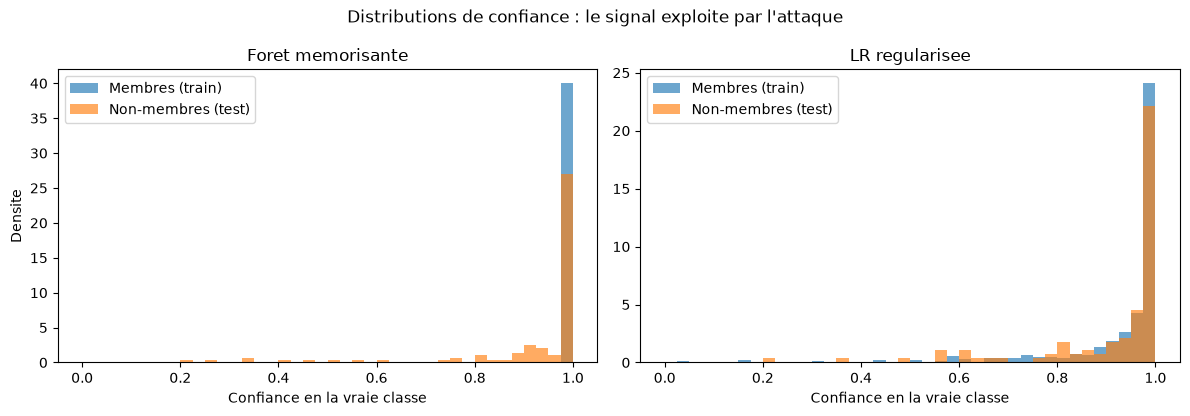

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
for ax, (nom, (p_mem, p_non)) in zip(axes, resultats_attaque.items()):
    ax.hist(p_mem, bins=40, range=(0, 1), alpha=0.65, density=True, label="Membres (train)")
    ax.hist(p_non, bins=40, range=(0, 1), alpha=0.65, density=True, label="Non-membres (test)")
    ax.set_title(nom)
    ax.set_xlabel("Confiance en la vraie classe")
    ax.legend()
axes[0].set_ylabel("Densite")
fig.suptitle("Distributions de confiance : le signal exploite par l'attaque")
plt.tight_layout()
plt.show()

### Interprétation : ce que montrent les distributions

À gauche, la forêt mémorisante : les membres forment une masse compacte collée à la confiance 1.0, tandis que les non-membres s'étalent vers des confiances plus faibles. Les deux distributions sont **séparées** — c'est visuellement cet écart entre les histogrammes qui vaut 0.439 d'avantage. À droite, la régression logistique régularisée : les deux distributions se recouvrent presque entièrement, l'attaquant ne peut pas tracer de frontière utile.

Une remarque importante pour la suite : cette séparation existe parce que le modèle a **le droit** de traiter chaque ligne d'entraînement individuellement. La confidentialité différentielle, que nous construisons maintenant, impose une contrainte mathématique qui interdit précisément cela : le modèle doit se comporter presque pareil **qu'une ligne soit présente ou absente** du jeu.

## 2. La confidentialité différentielle

### 2.0 La définition

La confidentialité différentielle (Dwork et al., 2006 ; synthèse dans Dwork et Roth, 2014) formalise l'idée : *changer une seule personne dans le jeu de données ne doit presque rien changer à la sortie de l'algorithme*. Un mécanisme aléatoire $\mathcal{M}$ est $(\varepsilon, \delta)$-différentiellement privé si pour tous jeux voisins $D$ et $D'$ (différant d'une ligne) et tout ensemble de sorties $S$ :

$$\Pr[\mathcal{M}(D) \in S] \;\leq\; e^{\varepsilon} \cdot \Pr[\mathcal{M}(D') \in S] + \delta$$

Deux paramètres :

- **epsilon** ($\varepsilon$) : le **budget de confidentialité**. Plus petit = plus privé. $\varepsilon = 0$ interdit toute influence de l'individu ; $\varepsilon$ grand autorise une influence forte.
- **delta** ($\delta$) : la probabilité d'échec de la garantie — la borne peut être violée avec probabilité au plus $\delta$. Usage courant : $\delta \ll 1/n$.

Le lien avec l'attaque de la partie 1 est direct : si la présence d'une ligne ne change presque rien à la distribution des sorties, alors **aucun attaquant, quelle que soit sa puissance, ne peut distinguer membre de non-membre** au-delà du facteur $e^{\varepsilon}$. La garantie est pire-cas : elle ne dépend ni du modèle, ni des données, ni de l'attaquant.

### 2.1 Le mécanisme de Laplace

Pour libérer une statistique numérique $f(D)$ (une moyenne, un comptage), le mécanisme le plus simple ajoute du bruit de Laplace calibré sur la **sensibilité** $\Delta f$ — l'ampleur maximale dont $f$ peut bouger quand une ligne change :

$$\mathcal{M}(D) = f(D) + \mathrm{Lap}\!\left(0, \frac{\Delta f}{\varepsilon}\right)$$

Nous l'implémentons **from scratch** ci-dessous. Cette implémentation est une **copie pédagogique déclarée** : son unique but est de montrer le mécanisme en quelques lignes de numpy ; pour un usage réel, les bibliothèques de référence (dont `diffprivlib`, utilisée en 2.4) fournissent des implémentations testées et un accounting exact.

In [5]:
def mecanisme_laplace(valeur, sensibilite, epsilon, rng):
    """Copie pedagogique : liberation differentiellement privee d'une statistique."""
    echelle = sensibilite / epsilon
    return valeur + rng.laplace(0.0, echelle)

# Demonstration : moyenne de la caracteristique 'mean radius' sur le train
colonne = 0
vraie_moyenne = float(X_train[:, colonne].mean())
sensibilite_moyenne = (X_train[:, colonne].max() - X_train[:, colonne].min()) / len(y_train)
rng = np.random.default_rng(0)

print(f"Moyenne vraie de 'mean radius' (train) : {vraie_moyenne:.3f}")
print(f"Sensibilite de la moyenne (adjacence ajout/retrait) : {sensibilite_moyenne:.4f}")
print()
print(f"{'epsilon':>8} | {'echelle b':>10} | {'|erreur| moyenne sur 2000 tirages':>34} | {'|erreur| q95':>12}")
for epsilon in [0.1, 1.0, 10.0]:
    erreurs = np.abs(np.array(
        [mecanisme_laplace(vraie_moyenne, sensibilite_moyenne, epsilon, rng) - vraie_moyenne
         for _ in range(2000)]))
    print(f"{epsilon:>8} | {sensibilite_moyenne / epsilon:>10.4f} | "
          f"{erreurs.mean():>34.4f} | {np.quantile(erreurs, 0.95):>12.4f}")

Moyenne vraie de 'mean radius' (train) : 14.067
Sensibilite de la moyenne (adjacence ajout/retrait) : 0.0464

 epsilon |  echelle b |  |erreur| moyenne sur 2000 tirages | |erreur| q95
     0.1 |     0.4644 |                             0.4740 |       1.4558
     1.0 |     0.0464 |                             0.0456 |       0.1335
    10.0 |     0.0046 |                             0.0047 |       0.0138


### Interprétation : le bruit est calibré par le budget

**Sortie obtenue** : la moyenne vraie de `mean radius` vaut 14.067 et la sensibilité de cette moyenne vaut 0.0464. L'erreur absolue moyenne du mécanisme passe de 0.474 à epsilon 0.1, à 0.046 à epsilon 1, puis à 0.005 à epsilon 10.

| epsilon | Échelle du bruit b | Erreur absolue moyenne | Erreur q95 |
|---------|---------------------|------------------------|------------|
| 0.1 | 0.4644 | 0.474 | 1.456 |
| 1.0 | 0.0464 | 0.046 | 0.134 |
| 10.0 | 0.0046 | 0.005 | 0.014 |

**Points clés** :

1. L'erreur moyenne est **exactement proportionnelle à b**, donc à $1/\varepsilon$ : chaque décade de budget divise l'erreur par dix. Le compromis utilité/confidentialité est ici une simple loi d'échelle.
2. La sensibilité $\Delta f$ entre linéairement dans le bruit : libérer une statistique instable (forte sensibilité) coûte très cher en exactitude. Une moyenne sur 455 tumeurs est peu sensible ; un maximum serait catastrophique.
3. La garantie est **pire-cas et prouvée** : contrairement à la partie 1 où nous mesurions une fuite a posteriori, ici nous **bornons a priori** ce que la sortie peut révéler — quel que soit l'attaquant.

La densité du bruit ajouté ci-dessous montre la même loi sous forme visuelle.

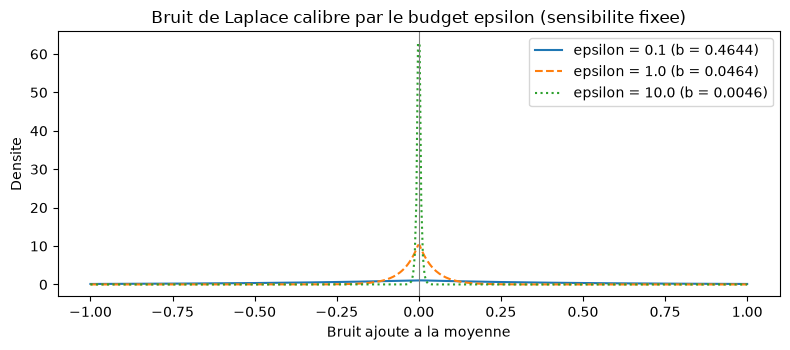

In [6]:
x_axis = np.linspace(-1.0, 1.0, 400)
plt.figure(figsize=(8, 3.6))
for epsilon, style in [(0.1, "-"), (1.0, "--"), (10.0, ":")]:
    b = sensibilite_moyenne / epsilon
    densite = np.exp(-np.abs(x_axis) / b) / (2 * b)
    plt.plot(x_axis, densite, style, label=f"epsilon = {epsilon} (b = {b:.4f})")
plt.axvline(0.0, color="gray", linewidth=0.8)
plt.xlabel("Bruit ajoute a la moyenne")
plt.ylabel("Densite")
plt.title("Bruit de Laplace calibre par le budget epsilon (sensibilite fixee)")
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation : le budget commande la largeur

À epsilon 0.1, la densité est large et presque plate sur tout l'intervalle : la sortie peut s'écarter de la vraie valeur d'une unité entière — la statistique est inutilisable mais la personne est invisible. À epsilon 10, le bruit se concentre en un pic étroit autour de zéro : la statistique est précise, mais le budget consommé est cent fois plus élevé. **Il n'y a pas de bon epsilon universel** ; il y a un choix de budget par acteur, en fonction de l'usage — c'est exactement l'objet de l'exercice 1.

Libérer une statistique est le cas simple. Nous voulons maintenant libérer **un modèle entier** : c'est le rôle du DP-SGD.

### 2.2 DP-SGD à la main

L'algorithme **DP-SGD** (Abadi et al., 2016) rend l'entraînement lui-même différentiellement privé, en trois ingrédients :

1. **Gradients par exemple** : calculer le gradient de la perte pour chaque ligne individuellement (pas la somme) ;
2. **Troncature à la norme C** : ramener chaque gradient individuel à une norme au plus $C$ — cela borne la sensibilité d'un pas à $C$, quoi que fasse une ligne isolée (c'est la barrière anti-mémorisation) ;
3. **Bruit gaussien** : ajouter au gradient agrégé un bruit $\mathcal{N}(0, z^2 C^2)$, où $z$ (le *multiplicateur de bruit*) est calibré pour atteindre le budget epsilon voulu après $T$ étapes.

L'entraînement est ici une **régression logistique** que nous écrivons entièrement en numpy — une seconde **copie pédagogique déclarée**, dont le but est de rendre chaque ingrédient visible. Pour l'accounting, nous utilisons la composition classique : borne gaussienne élémentaire $\varepsilon_0 = \sqrt{2 \ln(1.25/\delta_0)}/z$ par étape, puis composition avancée sur $T$ étapes. Ce choix est **pessimiste** : sans sous-échantillonnage (nous sommes en batch complet), pas d'amplification par l'échantillonnage, et notre borne est donc plus large que celle d'un accountant moderne. Nous verrons en 2.4 que cette prudence a un coût en utilité — et c'est un point pédagogique en soi.

Paramètres fixés pour toute la suite : $T = 30$ étapes, $C = 1.0$, $\delta = 10^{-5}$ (confortablement sous $1/455$), taux d'apprentissage 2.0.

In [7]:
def sigmoide(z):
    z = np.clip(z, -35.0, 35.0)
    return 1.0 / (1.0 + np.exp(-z))

def eps_etape(z, delta_etape):
    """Borne gaussienne classique par etape (valide pour eps_etape < 1)."""
    return np.sqrt(2.0 * np.log(1.25 / delta_etape)) / z

def eps_total(z, T, delta):
    """Composition avancee sur T etapes (Dwork, Rothblum et Vadhan, 2010)."""
    delta_etape = delta / T
    e0 = eps_etape(z, delta_etape)
    if e0 > 50.0:
        return 1e18
    return np.sqrt(2.0 * T * np.log(1.0 / delta)) * e0 + T * e0 * float(np.expm1(e0))

def z_pour_epsilon(epsilon, T, delta):
    """Resout le multiplicateur de bruit z pour un budget epsilon donne (Brent)."""
    return brentq(lambda z: eps_total(z, T, delta) - epsilon, 1e-3, 1e7)

def train_dpsgd(Xa, ya, T=30, C=1.0, lr=2.0, z=None, seed=0):
    """Regression logistique DP-SGD en numpy. z=None : version non privee."""
    rng = np.random.default_rng(seed)
    n = len(ya)
    X1 = np.hstack([Xa, np.ones((n, 1))])  # colonne constante pour l'ordonnee a l'origine
    w = np.zeros(X1.shape[1])
    for _ in range(T):
        p = sigmoide(X1 @ w)
        g = (p - ya)[:, None] * X1          # gradients par exemple
        normes = np.linalg.norm(g, axis=1)
        g = g * np.minimum(1.0, C / np.maximum(normes, 1e-12))[:, None]  # troncature a C
        g_somme = g.sum(axis=0)
        if z is not None:
            g_somme = g_somme + rng.normal(0.0, z * C, size=g_somme.shape)  # bruit gaussien
        w = w - lr * g_somme / n
    return w

def accuracy_modele(w, Xa, ya):
    X1 = np.hstack([Xa, np.ones((len(ya), 1))])
    return float(accuracy_score(ya, (sigmoide(X1 @ w) >= 0.5).astype(int)))

T_ETAPES, C_CLIP, DELTA = 30, 1.0, 1e-5
print(f"Multiplicateur de bruit z requis (T={T_ETAPES}, delta={DELTA:g}) :")
for eps in [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]:
    print(f"  epsilon = {eps:>5} -> z = {z_pour_epsilon(eps, T_ETAPES, DELTA):8.1f}")

Multiplicateur de bruit z requis (T=30, delta=1e-05) :
  epsilon =  0.25 -> z =    584.7
  epsilon =   0.5 -> z =    295.4
  epsilon =   1.0 -> z =    150.7
  epsilon =   2.0 -> z =     78.3
  epsilon =   4.0 -> z =     41.9
  epsilon =   8.0 -> z =     23.5


### Interprétation : le prix de la composition

**Sortie obtenue** : pour tenir un budget total de 0.25 après 30 étapes, il faut $z \approx 584.7$ ; pour un budget de 8, $z \approx 23.5$ seulement.

Le multiplicateur de bruit se définit par étape, mais le budget se paie **en cumulé** : diviser epsilon par deux demande environ le double de bruit par étape. C'est la composition qui domine le coût — et la raison pour laquelle les implémentations sérieuses utilisent des accountants fins (moments accountant, RDP) et l'amplification par sous-échantillonnage pour réduire ce facteur. Notre accounting volontairement simple va donc **surestimer** le bruit nécessaire : nos modèles seront plus privés que leur étiquette nominale ne l'exige, au prix de l'utilité.

Vérifions l'effet concret sur un entraînement.

In [8]:
w_prive = train_dpsgd(X_train_s, y_train, T=T_ETAPES, C=C_CLIP, lr=2.0,
                       z=z_pour_epsilon(1.0, T_ETAPES, DELTA), seed=0)
w_libre = train_dpsgd(X_train_s, y_train, T=T_ETAPES, C=C_CLIP, lr=2.0, z=None, seed=0)
acc_prive = accuracy_modele(w_prive, X_test_s, y_test)
acc_libre = accuracy_modele(w_libre, X_test_s, y_test)
print(f"DP-SGD a epsilon = 1.0  : accuracy test = {acc_prive:.3f}")
print(f"Version non privee (z=0) : accuracy test = {acc_libre:.3f}")
print(f"Ecart d'utilite          : {acc_libre - acc_prive:.3f}")

DP-SGD a epsilon = 1.0  : accuracy test = 0.658
Version non privee (z=0) : accuracy test = 0.982
Ecart d'utilite          : 0.325


### Interprétation : le compromis sur un exemple

À epsilon 1.0 et pour la graine 0, l'entraînement privé tombe à 0.658 d'accuracy, contre 0.982 pour la version non privée du même algorithme — un écart de 0.325, alors même que la version privée reste au-dessus de la baseline majorité. Un point notable : la version non privée de notre boucle est **déterministe** (batch complet, sans bruit), donc son accuracy ne dépend pas de la graine ; tout l'aléatoire de la version privée vient du bruit gaussien ajouté au gradient. Et sur **un seul** tirage, cet aléatoire pèse lourd : la partie suivante le mesure systématiquement.

### 2.3 La courbe utilité/confidentialité

Une seule valeur d'epsilon ne dit rien : le compromis est une **courbe**. Nous balayons la grille $\varepsilon \in \{0.25, 0.5, 1, 2, 4, 8\}$ et répétons chaque entraînement sur **4 graines (0, 1, 7, 42)**, en rapportant moyenne et écart-type. La dispersion entre graines fait partie du résultat : un mécanisme bruité à faible budget doit être évalué sur sa variabilité, pas sur un tirage chanceux.

In [9]:
GRILLE_EPS = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
SEEDS = [0, 1, 7, 42]

courbe_toy = {}
for eps in GRILLE_EPS:
    z = z_pour_epsilon(eps, T_ETAPES, DELTA)
    accs = [accuracy_modele(train_dpsgd(X_train_s, y_train, T=T_ETAPES, C=C_CLIP, lr=2.0, z=z, seed=s),
                            X_test_s, y_test) for s in SEEDS]
    courbe_toy[eps] = (float(np.mean(accs)), float(np.std(accs)))

accs_libres = [accuracy_modele(train_dpsgd(X_train_s, y_train, T=T_ETAPES, C=C_CLIP, lr=2.0, z=None, seed=s),
                               X_test_s, y_test) for s in SEEDS]
courbe_toy["non_prive"] = (float(np.mean(accs_libres)), float(np.std(accs_libres)))

resume_toy = {eps: courbe_toy[eps] for eps in GRILLE_EPS}
print(f"{'epsilon':>8} | {'accuracy moyenne':>16} | {'ecart-type':>10}")
for eps in GRILLE_EPS:
    m, s = courbe_toy[eps]
    print(f"{eps:>8} | {m:>16.3f} | {s:>10.3f}")
m, s = courbe_toy["non_prive"]
print(f"{'non prive':>8} | {m:>16.3f} | {s:>10.3f}")
print(f"Baseline majorite : {baseline_majorite:.3f}")

 epsilon | accuracy moyenne | ecart-type
    0.25 |            0.456 |      0.063
     0.5 |            0.643 |      0.100
     1.0 |            0.809 |      0.091
     2.0 |            0.886 |      0.035
     4.0 |            0.925 |      0.010
     8.0 |            0.952 |      0.004
non prive |            0.982 |      0.000
Baseline majorite : 0.632


### Interprétation : la courbe mesurée

**Sortie obtenue** : l'accuracy moyenne monte de 0.456 (epsilon 0.25) à 0.952 (epsilon 8), la version non privée plafonnant à 0.982 avec un écart-type de 0.000 — déterministe, donc.

| epsilon | Accuracy moyenne | Écart-type | Lecture |
|---------|------------------|------------|---------|
| 0.25 | 0.456 | 0.063 | modèle détruit, sous la baseline majorité |
| 0.5 | 0.643 | 0.100 | à peine la baseline (0.632) |
| 1.0 | 0.809 | 0.091 | premier epsilon utile |
| 2.0 | 0.886 | 0.035 | compromis raisonnable |
| 4.0 | 0.925 | 0.010 | proche du plateau |
| 8.0 | 0.952 | 0.004 | presque la version non privée |

**Points clés** :

1. La courbe est **monotone et concave** : les premiers points de budget sont les plus chers en utilité, les derniers presque gratuits. Passer de 4 à 8 ne gagne que 0.027 d'accuracy.
2. L'**écart-type se resserre à mesure que le budget augmente** (0.100 vers 0.004) : plus de bruit, c'est aussi plus d'aléatoire entre exécutions — la variabilité est une dimension de la confidentialité, pas un défaut de protocole.
3. À epsilon 0.25, le modèle est **sous** la baseline majorité : trop de bruit peut produire un modèle pire qu'inutile. Un budget DP ne se choisit pas « le plus petit possible » par réflexe.

La même courbe en figure, avec les repères que sont la baseline majorité et le modèle non privé.

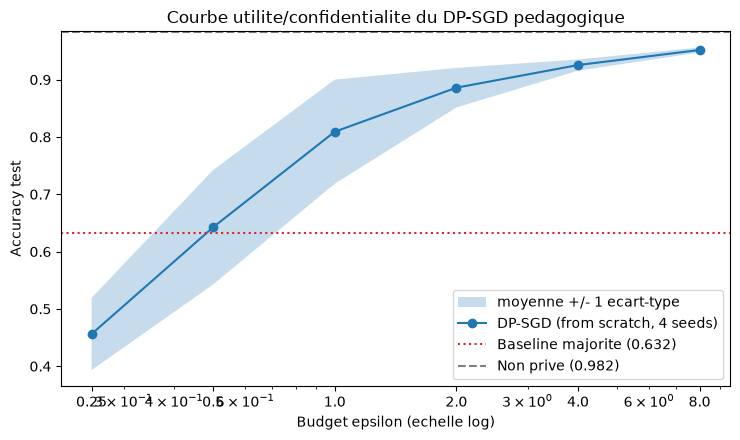

In [10]:
eps_x = GRILLE_EPS
moyennes = [courbe_toy[e][0] for e in eps_x]
ecarts = [courbe_toy[e][1] for e in eps_x]
m_libre = courbe_toy["non_prive"][0]

plt.figure(figsize=(7.5, 4.5))
plt.fill_between(eps_x, np.array(moyennes) - np.array(ecarts),
                 np.array(moyennes) + np.array(ecarts), alpha=0.25, label="moyenne +/- 1 ecart-type")
plt.plot(eps_x, moyennes, "o-", label="DP-SGD (from scratch, 4 seeds)")
plt.axhline(baseline_majorite, color="tab:red", linestyle=":", label=f"Baseline majorite ({baseline_majorite:.3f})")
plt.axhline(m_libre, color="tab:gray", linestyle="--", label=f"Non prive ({m_libre:.3f})")
plt.xscale("log")
plt.xticks(eps_x, [str(e) for e in eps_x])
plt.xlabel("Budget epsilon (echelle log)")
plt.ylabel("Accuracy test")
plt.title("Courbe utilite/confidentialite du DP-SGD pedagogique")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Interprétation : lire la courbe comme un arbitrage

La bande claire (écart-type) est large à gauche et se referme à droite : le compromis n'est pas une ligne mais un **cône**. Un décideur qui exige une accuracy minimale lit la courbe de droite à gauche et prend le premier epsilon qui sort du cône vers le haut — c'est littéralement l'exercice 1. Un décideur qui exige une confidentialité maximale lit de gauche à droite et accepte le coût d'utilité. La courbe ne dit pas lequel a raison ; elle rend le choix **explicite et chiffré**.

Reste la question centrale : notre implémentation pédagogique est-elle crédible ? C'est ce que tranche la comparaison avec la bibliothèque de référence du domaine.

### 2.4 Comparaison avec la bibliothèque de référence : diffprivlib (IBM)

`diffprivlib` (Holohan et al., 2019) est la bibliothèque de référence IBM pour la confidentialité différentielle ; sa `LogisticRegression` enveloppe l'entraînement d'une régression logistique avec une garantie DP et un accounting exact. Nous la lançons **sur les mêmes données, la même grille d'epsilon et les mêmes graines** que notre implémentation.

Deux choix d'appel, annoncés : `data_norm=21.5` borne la norme L2 des lignes (marge au-dessus de la norme maximale mesurée sur le train en 1.1 — convention des exemples de la bibliothèque ; une pratique stricte fixerait la borne avant de voir les données), et `C=10` réduit la régularisation : avec la valeur par défaut `C=1`, nous avons observé des effondrements de l'optimiseur interne à certains epsilon, et la comparaison porte sur un appel stable. Enfin, une mise en garde de lecture : **les epsilon nominaux de deux mécanismes différents ne sont pas interchangeables** — notre accounting pessimiste rend nos modèles plus privés que leur étiquette, la garantie stricte de la bibliothèque est plus proche de son étiquette.

In [11]:
courbe_dpl = {}
for eps in GRILLE_EPS:
    accs = []
    for s in SEEDS:
        modele = DPLogisticRegression(epsilon=eps, data_norm=21.5, C=10.0,
                                      random_state=s).fit(X_train_s, y_train)
        accs.append(float(accuracy_score(y_test, modele.predict(X_test_s))))
    courbe_dpl[eps] = (float(np.mean(accs)), float(np.std(accs)))

print(f"{'epsilon':>8} | {'DP-SGD maison (moy +/- sd)':>26} | {'diffprivlib (moy +/- sd)':>24}")
for eps in GRILLE_EPS:
    m1, s1 = courbe_toy[eps]
    m2, s2 = courbe_dpl[eps]
    print(f"{eps:>8} | {m1:>14.3f} +/- {s1:<8.3f} | {m2:>12.3f} +/- {s2:<8.3f}")

 epsilon | DP-SGD maison (moy +/- sd) | diffprivlib (moy +/- sd)
    0.25 |          0.456 +/- 0.063    |        0.629 +/- 0.186   
     0.5 |          0.643 +/- 0.100    |        0.675 +/- 0.158   
     1.0 |          0.809 +/- 0.091    |        0.730 +/- 0.117   
     2.0 |          0.886 +/- 0.035    |        0.798 +/- 0.049   
     4.0 |          0.925 +/- 0.010    |        0.838 +/- 0.034   
     8.0 |          0.952 +/- 0.004    |        0.886 +/- 0.027   


### Interprétation : deux courbes, deux accountings

**Sortie obtenue** (moyennes sur 4 graines) : notre DP-SGD passe de 0.456 à epsilon 0.25 à 0.952 à epsilon 8 ; la `LogisticRegression` de diffprivlib passe de 0.629 à 0.886 sur la même grille, avec un écart-type de 0.186 au point le plus bruité contre 0.027 au plus serré.

La figure ci-dessous superpose les deux courbes avec leurs bandes de dispersion.

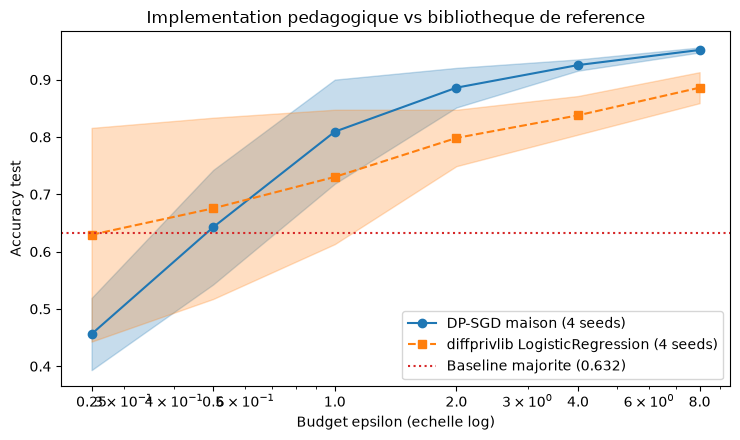

In [12]:
moyennes_dpl = [courbe_dpl[e][0] for e in GRILLE_EPS]
ecarts_dpl = [courbe_dpl[e][1] for e in GRILLE_EPS]

plt.figure(figsize=(7.5, 4.5))
plt.fill_between(eps_x, np.array(moyennes) - np.array(ecarts), np.array(moyennes) + np.array(ecarts),
                 alpha=0.25, color="tab:blue")
plt.plot(eps_x, moyennes, "o-", color="tab:blue", label="DP-SGD maison (4 seeds)")
plt.fill_between(eps_x, np.array(moyennes_dpl) - np.array(ecarts_dpl), np.array(moyennes_dpl) + np.array(ecarts_dpl),
                 alpha=0.25, color="tab:orange")
plt.plot(eps_x, moyennes_dpl, "s--", color="tab:orange", label="diffprivlib LogisticRegression (4 seeds)")
plt.axhline(baseline_majorite, color="tab:red", linestyle=":", label=f"Baseline majorite ({baseline_majorite:.3f})")
plt.xscale("log")
plt.xticks(eps_x, [str(e) for e in eps_x])
plt.xlabel("Budget epsilon (echelle log)")
plt.ylabel("Accuracy test")
plt.title("Implementation pedagogique vs bibliotheque de reference")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Verdict SOTA : cohérent en tendance, divergent en ampleur

**Ce qui est cohérent.** Les deux courbes racontent la même histoire : monotonie (l'utilité croît avec le budget), convergence vers la zone du modèle non privé aux grands epsilon, forte dispersion à faible budget, et un point de croisement de la baseline majorité autour d'epsilon 0.25-0.5. L'ordre de grandeur du coût (quelques dixièmes d'accuracy pour passer de non privé à epsilon 1-2) est le même des deux côtés. Notre implémentation pédagogique capture donc bien le **phénomène**.

**Où elles divergent.** Sur cette grille et ce jeu de données, notre DP-SGD maison domine la référence à partir d'epsilon 2 (0.886 contre 0.798) et atteint 0.952 à epsilon 8 contre 0.886 pour diffprivlib ; à epsilon 0.25, c'est l'inverse (0.456 contre 0.629), la référence restant au niveau de la baseline là où notre modèle s'effondre en dessous. Cette inversion n'est pas une victoire de notre implémentation : elle vient de **l'asymétrie des accountings**. La garantie de diffprivlib est exacte pour l'epsilon affiché, la nôtre est volontairement pessimiste (composition avancée grossière, sans amplification par sous-échantillonnage) — à epsilon nominal égal, nos modèles sont en réalité plus privés que l'étiquette ne le dit, donc plus utiles. Comparer deux epsilon nominaux issus d'accountings différents, c'est comparer des choses différentes.

**Statut SOTA-OK pour la comparaison elle-même** : la bibliothèque de référence du domaine est réellement installée et invoquée (version affichée en 1.0), sur les mêmes données, la même grille et les mêmes graines ; l'implémentation from scratch est déclarée et encadrée comme copie pédagogique. **Recommandation pratique** : pour tout usage réel, utiliser diffprivlib (ou Opacus / TensorFlow Privacy pour l'apprentissage profond) plutôt que du code maison — l'accounting est la partie la plus facile à mal écrire.

## 3. Documenter : la datasheet et la model card

Mesurer la fuite (partie 1) et la borner (partie 2) ne suffisent pas : un jeu de données et un modèle ne sont responsabilisés que s'ils sont **documentés pour un tiers**. Deux artefacts sont devenus le standard du domaine :

- la **datasheet** (Gebru et al., 2021) : la fiche d'identité du jeu de données — pourquoi il existe, comment il a été collecté, ce qu'il contient, ce qu'on a le droit d'en faire ;
- la **model card** (Mitchell et al., 2019) : la fiche d'identité du modèle — pour quoi il est fait, sur quoi il a été entraîné, ce qu'il vaut, où il ne doit pas être utilisé.

L'esprit est le même que le geste du praticien de **2.13-Analyse-Erreurs** : sortir de la moyenne globale et dire précisément les conditions d'un résultat. Les deux tableaux ci-dessous sont remplis avec le **contenu réel** de ce notebook — données réellement chargées, modèle réellement entraîné, chiffres réellement mesurés plus haut.

### 3.1 Datasheet du jeu de données

| Champ | Contenu (valeurs mesurées dans ce notebook) |
|-------|---------------------------------------------|
| **Motivation** | Fournir un jeu médical réel, petit et canonique, pour étudier mémorisation et confidentialité ; c'est le jeu de référence de la littérature DP (dont la documentation diffprivlib). |
| **Composition** | 569 tumeurs x 30 caractéristiques numériques (rayons, textures, périmètres... calculés sur des images de ponctions) ; cible binaire : 212 malignes, 357 bénignes. Découpe utilisée ici : 455 train / 114 test (stratifiée, graine 42). |
| **Collecte** | Ponctions aspiratives fines de patientes, University of Wisconsin, images numérisées puis traitées par un programme d'extraction de caractéristiques (Street, Wolberg et Mangasarian, 1993). Aucune donnée collectée par nos soins. |
| **Prétraitement** | Standardisation (moyenne/écart-type du train uniquement) ; norme L2 max d'une ligne : 21.04 ; borne déclarée pour l'entraînement DP : 21.5. |
| **Usages recommandés** | Enseignement et recherche (classification binaire, confidentialité, équité) ; notre usage : démonstration d'attaque par inférence d'appartenance et d'entraînement DP. |
| **Usages déconseillés** | Toute décision clinique réelle : le jeu date de 1993, est petit, et nos modèles sont pédagogiques. |
| **Distribution** | Distribué par scikit-learn (`load_breast_cancer`), donc lié à la version de la bibliothèque affichée en 1.0 ; données publiques d'origine UCI. |
| **Maintenance** | Aucune collecte additionnelle ; le contenu suit les versions scikit-learn. |
| **Remarque confidentialité** | Nous jouons le scénario où l'appartenance au jeu d'entraînement est une information sensible ; l'attaque de la partie 1 montre que ce scénario n'est pas théorique. |

**Lecture** : une datasheet utile est une datasheet qui informe une décision. Ici, un relecteur apprend en trente secondes que le jeu est médical, vieux de trois décennies, déséquilibré (37 % de malignes), standardisé sur le train seulement, et utilisé sous scénario sensible — autant d'éléments qui manquent dans « accuracy 0.97 sur breast cancer ».

### 3.2 Model card du modèle de ce notebook

| Champ | Contenu |
|-------|---------|
| **Détails du modèle** | Régression logistique (31 poids, numpy) entraînée par DP-SGD maison : batch complet, T = 30 étapes, troncature de gradient C = 1.0, bruit gaussien calibré par composition avancée, delta = 1e-5. Copie pédagogique déclarée. |
| **Entraînement** | 455 tumeurs standardisées du jeu Breast Cancer Wisconsin (cf. datasheet 3.1) ; aucune donnée externe. |
| **Version documentée** | Le point epsilon = 4.0 : accuracy test 0.925 +/- 0.010 (moyenne sur 4 graines, mesurée en 2.3). |
| **Métriques** | Accuracy test par epsilon (table de 2.3) : 0.456 à epsilon 0.25 jusqu'à 0.952 à epsilon 8 ; non privé : 0.982 ; baseline majorité : 0.632. |
| **Cas d'usage prévu** | Démonstration pédagogique du compromis utilité/confidentialité ; aucun usage de prédiction réelle. |
| **Facteurs de performance** | Budget epsilon (dominant), graine du bruit (à faible budget), borne de norme des données. |
| **Limites** | Accounting pessimiste (à epsilon nominal égal, la protection réelle consommée est inférieure à l'étiquette) ; pas d'amplification par sous-échantillonnage ; jeu unique, petit et ancien ; aucune évaluation d'équité par sous-groupes (cf. 2.5c-Equite-Sous-Groupes pour la méthode). |
| **Considérations éthiques** | Données médicales réelles de patientes ; la partie 1 démontre une fuite d'appartenance exploitable (+0.439 d'avantage d'attaque sur la forêt non protégée) ; la garantie DP appliquée ensuite est pire-cas et ne protège que l'appartenance, pas les attributs. |

**Lecture** : la model card assume ses limites au lieu de les laisser deviner — en particulier le statut « pédagogique » de l'accounting et le fait que la garantie DP couvre l'appartenance, pas l'ensemble des attaques possibles (reconstruction d'attributs, inversion de modèle). Une carte honnête court-circuite l'argument d'autorité : le lecteur sait exactement ce qu'il peut et ne peut pas conclure.

## 4. Exercices

Trois exercices, tous jouables avec les variables déjà définies dans ce notebook. Les stubs s'exécutent sans erreur : complétez-les, relancez la cellule, le résultat doit remplacer le `None`.

### Exercice 1 — Choisir epsilon sous contrainte d'utilité

**Contexte** : l'administrateur des données exige une accuracy test moyenne d'au moins **0.90** (sur 4 graines) et veut le **plus petit budget epsilon** qui la garantit — chaque point de budget non dépensé est de la confidentialité préservée.

**Objectif** : implémenter `epsilon_sous_contrainte(resume, seuil)` qui parcourt la grille par epsilon croissant et renvoie le premier dont la moyenne est au moins `seuil`, puis répondre : quel epsilon retenez-vous, et que perd-on en confidentialité par rapport au choix « epsilon = 8 par défaut » ?

- **Étape 1** — parcourir `sorted(resume)` (clés epsilon croissantes) ;
- **Étape 2** — pour chaque epsilon, lire la moyenne `resume[eps][0]` ;
- **Étape 3** — renvoyer le premier epsilon dont la moyenne est au moins `seuil`.
- **Indice** — `resume_toy` (cellule 2.3) contient `{epsilon: (moyenne, ecart-type)}` ; renvoyer `None` si aucun epsilon ne convient.

In [13]:
def epsilon_sous_contrainte(resume, seuil):
    """Renvoie le plus petit epsilon de la grille dont l'accuracy moyenne >= seuil."""
    # TODO etudiant : parcours par epsilon croissant et premiere moyenne >= seuil
    # Indice : resume[eps][0] est la moyenne ; comparer au seuil ; renvoyer eps
    print("Exercice a completer")
    return None  # TODO etudiant

choix = epsilon_sous_contrainte(resume_toy, 0.90)
print("Epsilon retenu sous contrainte d'utilite :", choix)

Exercice a completer
Epsilon retenu sous contrainte d'utilite : None


### Exercice 2 — Attaquer le modèle protégé

**Contexte** : la partie 1 a mesuré un avantage d'attaque de +0.439 contre la forêt non protégée. La question de suivi est empirique : est-ce que l'entraînement DP-SGD a **réduit** le signal d'attaque ?

**Objectif** : implémenter `avantage_attaque_dp(epsilon, seed)` qui ré-entraîne notre DP-SGD, calcule la confiance en la vraie classe sur train et test, en déduit l'AUC puis l'avantage $2 \cdot \mathrm{AUC} - 1$, et comparer le résultat à ceux de la partie 1.

- **Étape 1** — entraîner avec `train_dpsgd(..., z=z_pour_epsilon(epsilon, T_ETAPES, DELTA), seed=seed)` ;
- **Étape 2** — probabilités : `sigmoide(np.hstack([X, np.ones((n, 1))]) @ w)` ; en extraire la confiance en la vraie classe ;
- **Étape 3** — `roc_auc_score` sur membres contre non-membres, puis avantage.
- **Indice** — reprendre la structure de `attaque_appartenance` en remplaçant `predict_proba` par la sigmoïde.

In [14]:
def avantage_attaque_dp(epsilon=1.0, seed=0):
    """Avantage d'attaque par confiance contre le modele DP-SGD entraine ici."""
    # TODO etudiant : entrainer, scorer, calculer l'AUC puis l'avantage
    # Indice : sigmoide(X1 @ w) donne p(classe 1) ; la vraie classe est y
    print("Exercice a completer")
    return None  # TODO etudiant

avantage_dp = avantage_attaque_dp(epsilon=1.0, seed=0)
print("Avantage d'attaque contre le modele DP a epsilon 1 :", avantage_dp)

Exercice a completer
Avantage d'attaque contre le modele DP a epsilon 1 : None


### Exercice 3 — Une proportion privée par mécanisme de Laplace

**Contexte** : un journaliste demande « quelle proportion de malignes dans votre jeu ? » ; la réponse doit être différentiellement privée (epsilon = 1.0).

**Objectif** : implémenter `erreur_proportion_privee(epsilon, n_tirages, seed)` qui libère la proportion de la classe maligne dans le train via `mecanisme_laplace` et renvoie l'erreur absolue moyenne empirique sur `n_tirages` tirages.

- **Étape 1** — proportion vraie : `(y_train == 0).mean()` ; sensibilité d'une proportion (adjacence ajout/retrait) : `1 / len(y_train)` ;
- **Étape 2** — tirer `n_tirages` versions bruitées avec `mecanisme_laplace(..., rng)` ;
- **Étape 3** — renvoyer la moyenne des écarts absolus entre valeur bruitée et valeur vraie.
- **Indice** — un seul `np.random.default_rng(seed)` pour tous les tirages, comme en 2.1.

In [15]:
def erreur_proportion_privee(epsilon=1.0, n_tirages=1000, seed=0):
    """Erreur absolue moyenne de la proportion maligne liberee par Laplace."""
    # TODO etudiant : sensibilite = 1 / len(y_train) ; bruit Laplace ; erreur empirique
    # Indice : la proportion vraie est (y_train == 0).mean()
    print("Exercice a completer")
    return None  # TODO etudiant

erreur = erreur_proportion_privee(epsilon=1.0)
print("Erreur absolue moyenne de la proportion privee a epsilon 1 :", erreur)

Exercice a completer
Erreur absolue moyenne de la proportion privee a epsilon 1 : None


## 5. Conclusion

Ce notebook a tenu une promesse simple : la donnée d'entraînement est une **responsabilité mesurable**. Trois gestes l'ont structuré :

| Geste | Outil | Résultat clé (mesuré ici) |
|-------|-------|---------------------------|
| Mesurer la fuite | Attaque par inférence d'appartenance | Avantage +0.439 (forêt mémorisante) contre +0.057 (LR régularisée) |
| Borner la fuite | Mécanisme de Laplace, DP-SGD | Courbe 0.456 à 0.952 sur epsilon 0.25 à 8 ; non privé 0.982 |
| Confronter à la référence | diffprivlib (IBM) | Tendances cohérentes ; divergence d'ampleur expliquée par l'accounting |

**À retenir** :

1. **Un modèle utile peut être un modèle indiscret** : les deux modèles de la partie 1 ont des performances proches et des profils de fuite opposés. Évaluer un modèle sensible sans mesurer sa fuite, c'est ne regarder qu'une moitié de la fiche.
2. **La confidentialité différentielle est un budget, pas un booléen** : le compromis est une courbe chiffrée, avec de la dispersion ; la choisir est une décision de gouvernance (exercice 1), pas un réglage technique par défaut.
3. **Documenter fait partie du livrable** : la datasheet et la model card de la partie 3 coûtent vingt minutes et changent ce qu'un tiers peut légitimement conclure du travail.

Ce notebook prolonge le triptyque de l'évaluation de modèles ouvert par **2.5b-Calibration-Probabilites** (peut-on croire le score ?) et **2.5c-Equite-Sous-Groupes** (le score est-il équitable ?) par la troisième question : **que révèle le score sur les personnes ?**

### Références

- C. Dwork, A. Roth, *The Algorithmic Foundations of Differential Privacy*, Foundations and Trends in Theoretical Computer Science, 2014.
- M. Abadi, A. Chu, I. Goodfellow, H. B. McMahan, I. Mironov, K. Talwar, L. Zhang, *Deep Learning with Differential Privacy* (DP-SGD), ACM CCS, 2016.
- C. Dwork, G. N. Rothblum, S. Vadhan, *Boosting and Differential Privacy*, IEEE FOCS, 2010 (composition avancée).
- R. Shokri, M. Stronati, C. Song, V. Shmatikov, *Membership Inference Attacks Against Machine Learning Models*, IEEE S&P, 2017.
- A. Salem, Y. Zhang, M. Humbert, P. Berrang, M. Fritz, M. Backes, *ML-Leaks: Model and Data Independent Membership Inference Attacks and Defenses on Machine Learning Models*, ICLR, 2019 (convention de l'avantage d'attaque).
- T. Gebru, J. Morgenstern, B. Vecchione, J. W. Vaughan, H. Wallach, H. Daumé III, K. Crawford, *Datasheets for Datasets*, Communications of the ACM, 2021.
- M. Mitchell et al., *Model Cards for Model Reporting*, ACM FAT*, 2019.
- N. Holohan, S. Braghin, P. Mac Aonghusa, K. Levacher, *Diffprivlib: The IBM Differential Privacy Library*, Journal of Privacy and Confidentiality, 2019.
- W. N. Street, W. H. Wolberg, O. L. Mangasarian, *Nuclear feature extraction for breast tumor diagnosis*, IS&T/SPIE, 1993 (jeu de données).